In [1]:
import torch
import torch_geometric
from torch_geometric.data import Data
# Import GCNConv
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GINConv
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os

from torch.func import jacrev

plt.style.use(os.path.join("figures", "matlab.mplstyle"))

# Section 3.1 or 3.2

from notebook_utils import HALF_FIGSIZE, BIG_FIGSIZE, MAKE_STANDARD_LEGEND, PLOT_KWARGS

In [2]:
def create_flat_graph(num_neighbors, dimension):
    num_nodes = num_neighbors + 1  # Including the central node
    # Create a graph in which all neighbors are connected to the central node
    edge_index = torch.tensor(
        [
            [i for i in range(1, num_nodes)],  # Source nodes (neighbors)
            [0 for _ in range(1, num_nodes)],  # Target node (central node)
        ],
        dtype=torch.long,
    )
    # row, col = edge_index
    # rev_edge_index = torch.stack([col, row], dim=0)
    # # Make undirected for accurate comparison to NAR
    # edge_index = torch.cat([edge_index, rev_edge_index], dim=1)
    # Random feature vectors for each node
    x = torch.randn((num_nodes, dimension), dtype=torch.float)
    # Create a graph data object
    graph = Data(x=x, edge_index=edge_index, num_nodes=num_nodes)
    return graph

def create_deep_graph(num_neighbors, dimension):
    # We will create a binary tree, so check num of neighbors is a power of 2
    assert (num_neighbors & (num_neighbors - 1)) == 0 and num_neighbors != 0, "num_neighbors must be a power of 2"
    leaf_nodes = [0]
    # Initially this list just contains the random feature vector for the root node
    x_list = [torch.randn((1, dimension), dtype=torch.float)]
    edge_index_list = []
    depth = 0
    # We will iteratively build the tree level by level, until we have enough leaf nodes
    while len(leaf_nodes) < num_neighbors:
        new_leaf_nodes = []
        for leaf_node in leaf_nodes:
            left_node_feature = torch.randn((1, dimension), dtype=torch.float)
            right_node_feature = torch.randn((1, dimension), dtype=torch.float)
            left_node_index = len(x_list)
            x_list.append(left_node_feature)
            right_node_index = len(x_list)
            x_list.append(right_node_feature)

            edge_index_list.append((left_node_index, leaf_node))
            edge_index_list.append((right_node_index, leaf_node))

            new_leaf_nodes.append(left_node_index)
            new_leaf_nodes.append(right_node_index)
        depth += 1
        leaf_nodes = new_leaf_nodes
    
    x = torch.cat(x_list, dim=0)
    edge_index = torch.tensor(edge_index_list, dtype=torch.long).T

    graph = Data(x=x, edge_index=edge_index, num_nodes=len(x))
    return graph, depth

def get_gcn(num_layers, dimension, activation_class):
    class GCN(nn.Module):
        def __init__(self):
            super().__init__()
            self.convs = nn.ModuleList([
                GCNConv(dimension, dimension) for _ in range(num_layers)
            ])
            self.activations = nn.ModuleList([
                activation_class() for _ in range(num_layers-1)
            ])
            
        def forward(self, x, edge_index):
            for conv, activation in zip(self.convs[:-1], self.activations):
                x = activation(conv(x, edge_index))
            x = self.convs[-1](x, edge_index)
            return x
            
    return GCN()

def get_jacobian_norms(num_neighbors, dimension, activation_class, repeats):
    deep_graph_jacobian_norms = []
    shallow_graph_jacobian_norms = []
    for _ in range(repeats):
        deep_graph, depth = create_deep_graph(num_neighbors, dimension)
        shallow_graph = create_flat_graph(num_neighbors, dimension)
        deepgcn = get_gcn(depth, dimension, activation_class)
        shallowgcn = get_gcn(1, dimension, activation_class)
        jac_func = lambda x, edge_index, gcn : gcn(x, edge_index)[0]
        deepjacobian = jacrev(jac_func, argnums=0)(deep_graph.x, deep_graph.edge_index, deepgcn)[:, -num_neighbors:, :]
        shallowjacobian = jacrev(jac_func, argnums=0)(shallow_graph.x, shallow_graph.edge_index, shallowgcn)[:, -num_neighbors:, :]
        deepjacobian_norms = torch.norm(deepjacobian.reshape(num_neighbors, -1), p=1, dim=1)
        shallowjacobian_norms = torch.norm(shallowjacobian.reshape(num_neighbors, -1), p=1, dim=1)
        deep_graph_jacobian_norms.extend(deepjacobian_norms.tolist())
        shallow_graph_jacobian_norms.extend(shallowjacobian_norms.tolist())
    
    return deep_graph_jacobian_norms, shallow_graph_jacobian_norms


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


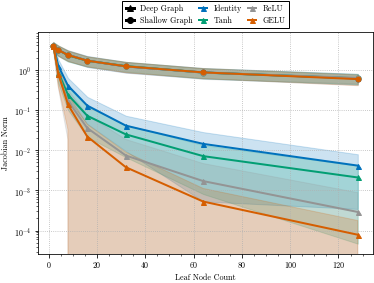

In [7]:
fig, ax = plt.subplots(figsize=(HALF_FIGSIZE[0], 1.5))
dimension = 4
repeats = 100
all_num_neighbors = 2**np.arange(1, 8)

activation_fns = [nn.Identity, nn.Tanh, nn.ReLU, nn.GELU]
# First plot empty lines for the architecture legend entries
line1, = ax.plot([], [], '-', marker='^', label='Deep Graph', markersize=6, color='black')
line2, = ax.plot([], [], '-', marker='o', label='Shallow Graph', markersize=6, color='black')
# Use the color from the first lines for consistency
arch_color = line1.get_color()
line1.set_color(arch_color)
line2.set_color(arch_color)

for act_fn in activation_fns:
    deep_graph_jacobian_norm_means = []
    deep_graph_jacobian_norm_stds = []
    shallow_graph_jacobian_norm_means = []
    shallow_graph_jacobian_norm_stds = []

    for num_neighbors in all_num_neighbors:
        deep_graph_jacobian_norms, shallow_graph_jacobian_norms = get_jacobian_norms(num_neighbors, dimension, act_fn, repeats)
        deep_graph_jacobian_norm_means.append(np.mean(deep_graph_jacobian_norms))
        deep_graph_jacobian_norm_stds.append(np.std(deep_graph_jacobian_norms))
        shallow_graph_jacobian_norm_means.append(np.mean(shallow_graph_jacobian_norms))
        shallow_graph_jacobian_norm_stds.append(np.std(shallow_graph_jacobian_norms))

    # Plot deep graph line with triangular markers and shaded error region
    line, = ax.plot(all_num_neighbors, deep_graph_jacobian_norm_means,
            linestyle='-',
            marker='^',
            label=act_fn.__name__,
            **PLOT_KWARGS)
    color = line.get_color()  # Get matplotlib's assigned color
    ax.fill_between(all_num_neighbors,
                    np.array(deep_graph_jacobian_norm_means) - np.array(deep_graph_jacobian_norm_stds),
                    np.array(deep_graph_jacobian_norm_means) + np.array(deep_graph_jacobian_norm_stds),
                    color=color,
                    alpha=0.2)

    # Plot shallow graph line with circular markers and shaded error region 
    line, = ax.plot(all_num_neighbors, shallow_graph_jacobian_norm_means,
            linestyle='-',
            marker='o',
            color=color,
            **PLOT_KWARGS)
    ax.fill_between(all_num_neighbors,
                    np.array(shallow_graph_jacobian_norm_means) - np.array(shallow_graph_jacobian_norm_stds),
                    np.array(shallow_graph_jacobian_norm_means) + np.array(shallow_graph_jacobian_norm_stds),
                    color=color,
                    alpha=0.2)

ax.set_yscale('log')
ax.set_xlabel('Leaf Node Count')
ax.set_ylabel('Jacobian Norm')

MAKE_STANDARD_LEGEND(ax, 3)

plt.savefig(os.path.join("figures", "flat_vs_deep_sensitivity.pdf"))

plt.gcf().set_size_inches(6, 4)
plt.show()